## 1. Setup


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, roc_auc_score, average_precision_score,
)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

EXPERIMENT = "001_best_solution"
PROJECT_ROOT = Path("..")
REPORT_DIR = PROJECT_ROOT / "reports" / EXPERIMENT

oof = pd.read_csv(REPORT_DIR / "oof_predictions.csv")
metrics = json.loads((REPORT_DIR / "metrics.json").read_text(encoding="utf-8"))
importance = pd.read_csv(REPORT_DIR / "feature_importance.csv")
importance_by_fold = pd.read_csv(REPORT_DIR / "feature_importance_by_fold.csv")

train = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "train.csv")
print(f"OOF: {oof.shape}, train: {train.shape}")

OOF: (891, 5), train: (891, 12)


## 2. Fold scores


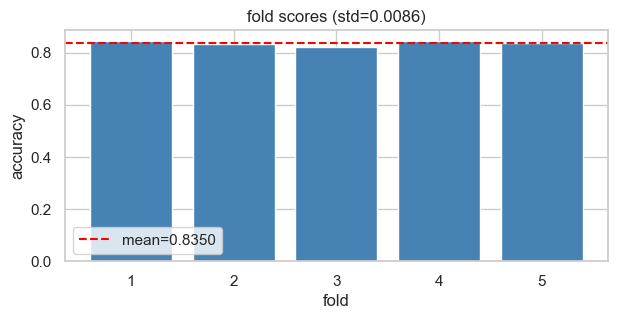

In [2]:
scores = metrics["fold_scores"]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, len(scores) + 1), scores, color="steelblue")
ax.axhline(np.mean(scores), color="red", linestyle="--", label=f"mean={np.mean(scores):.4f}")
ax.set_xlabel("fold")
ax.set_ylabel("accuracy")
ax.set_title(f"fold scores (std={np.std(scores):.4f})")
ax.legend()
plt.show()

## 3. Confusion matrix


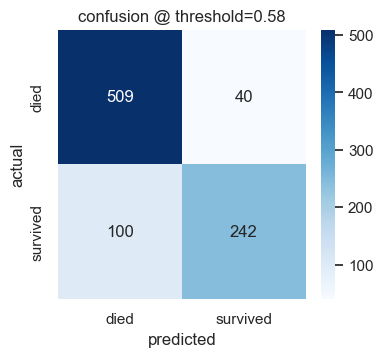

In [3]:
y_true = oof["Survived"].to_numpy()
y_proba = oof["probability"].to_numpy()
y_pred = oof["prediction"].to_numpy()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["died", "survived"], yticklabels=["died", "survived"])
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title(f"confusion @ threshold={metrics['best_threshold']:.2f}")
plt.show()

## 4. Classification report


In [4]:
print(classification_report(y_true, y_pred, target_names=["died", "survived"], digits=4))

              precision    recall  f1-score   support

        died     0.8358    0.9271    0.8791       549
    survived     0.8582    0.7076    0.7756       342

    accuracy                         0.8429       891
   macro avg     0.8470    0.8174    0.8274       891
weighted avg     0.8444    0.8429    0.8394       891



## 5. ROC and PR curves


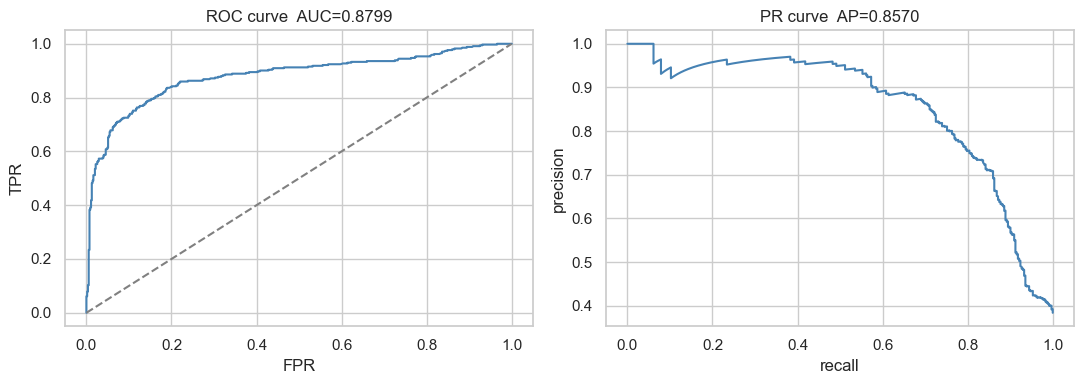

In [5]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
precision, recall, _ = precision_recall_curve(y_true, y_proba)
roc_auc = roc_auc_score(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(fpr, tpr, color="steelblue")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC curve  AUC={roc_auc:.4f}")

axes[1].plot(recall, precision, color="steelblue")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title(f"PR curve  AP={ap:.4f}")

fig.tight_layout()
plt.show()

### 5.1 ROC AUC по разбиениям


,metric,roc_auc
0,overall,0.879875
1,mean_by_fold,0.883704
2,std_by_fold,0.014391


,fold,roc_auc
0,0,0.902899
1,1,0.886898
2,2,0.864906
3,3,0.869719
4,4,0.894097


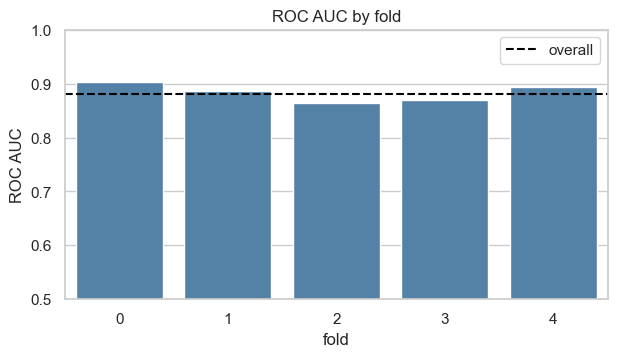

In [6]:
roc_auc_by_fold = pd.DataFrame([
    {
        "fold": fold,
        "roc_auc": roc_auc_score(part["Survived"], part["probability"]),
    }
    for fold, part in oof.groupby("fold")
])

roc_auc_summary = pd.DataFrame({
    "metric": ["overall", "mean_by_fold", "std_by_fold"],
    "roc_auc": [
        roc_auc_score(y_true, y_proba),
        roc_auc_by_fold["roc_auc"].mean(),
        roc_auc_by_fold["roc_auc"].std(ddof=0),
    ],
})

display(roc_auc_summary)
display(roc_auc_by_fold)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=roc_auc_by_fold, x="fold", y="roc_auc", color="steelblue", ax=ax)
ax.axhline(roc_auc_summary.loc[0, "roc_auc"], color="black", linestyle="--", label="overall")
ax.set_ylim(0.5, 1.0)
ax.set_xlabel("fold")
ax.set_ylabel("ROC AUC")
ax.set_title("ROC AUC by fold")
ax.legend()
plt.show()


## 6. Probability distribution and calibration


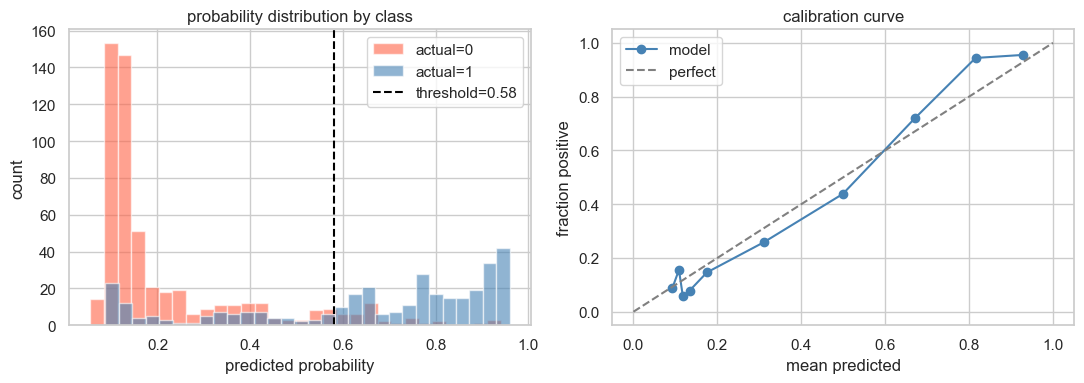

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 6a — гистограмма
for label, color in [(0, "tomato"), (1, "steelblue")]:
    axes[0].hist(
        y_proba[y_true == label], bins=30, alpha=0.6,
        label=f"actual={label}", color=color,
    )
axes[0].axvline(metrics["best_threshold"], color="black", linestyle="--",
                label=f"threshold={metrics['best_threshold']:.2f}")
axes[0].set_xlabel("predicted probability")
axes[0].set_ylabel("count")
axes[0].set_title("probability distribution by class")
axes[0].legend()

# 6b — calibration
prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10, strategy="quantile")
axes[1].plot(prob_pred, prob_true, marker="o", color="steelblue", label="model")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="perfect")
axes[1].set_xlabel("mean predicted")
axes[1].set_ylabel("fraction positive")
axes[1].set_title("calibration curve")
axes[1].legend()

fig.tight_layout()
plt.show()

## 7. Feature importance


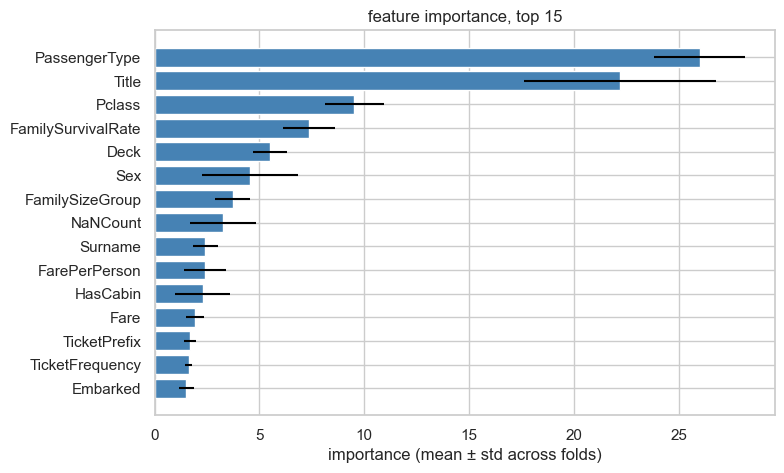


top with stability (cv = std/mean):
           feature  mean_importance  std_importance    cv
     PassengerType        26.003237        2.177548 0.084
             Title        22.207479        4.559224 0.205
            Pclass         9.534925        1.392388 0.146
FamilySurvivalRate         7.373770        1.239781 0.168
              Deck         5.515154        0.807695 0.146
               Sex         4.547742        2.289653 0.503
   FamilySizeGroup         3.715681        0.856345 0.230
          NaNCount         3.264409        1.580698 0.484
           Surname         2.416816        0.609868 0.252
     FarePerPerson         2.403776        0.997486 0.415
          HasCabin         2.282203        1.327049 0.581
              Fare         1.926388        0.434502 0.226
      TicketPrefix         1.677276        0.285527 0.170
   TicketFrequency         1.614664        0.185815 0.115
          Embarked         1.514817        0.340143 0.225


In [8]:
top = importance.head(15).copy()
top["cv"] = (top["std_importance"] / top["mean_importance"]).round(3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"][::-1], top["mean_importance"][::-1],
        xerr=top["std_importance"][::-1], color="steelblue", ecolor="black")
ax.set_xlabel("importance (mean ± std across folds)")
ax.set_title("feature importance, top 15")
plt.show()

print("\ntop with stability (cv = std/mean):")
print(top[["feature", "mean_importance", "std_importance", "cv"]].to_string(index=False))

## 8. Error analysis


In [9]:
# Прицепляем сырые признаки к OOF — для срезов
errors = oof.merge(train[["PassengerId", "Sex", "Pclass", "Age"]], on="PassengerId")
errors["correct"] = errors["Survived"] == errors["prediction"]

print("accuracy by Sex × Pclass:")
print(
    errors.groupby(["Sex", "Pclass"])["correct"].mean().round(3).unstack()
)

accuracy by Sex × Pclass:
Pclass      1      2      3
Sex                        
female  0.968  0.908  0.736
male    0.631  0.926  0.888


In [10]:
# High-confidence wrong predictions — потенциально мислейблы или сложные кейсы
wrong = errors[~errors["correct"]].copy()
wrong["confidence"] = (wrong["probability"] - 0.5).abs() + 0.5

worst = wrong.sort_values("confidence", ascending=False).head(10)
worst[["PassengerId", "Survived", "prediction", "probability", "Sex", "Pclass", "Age"]]

,PassengerId,Survived,prediction,probability,Sex,Pclass,Age
177,178,0,1,0.941068,female,1,50.0
498,499,0,1,0.936432,female,1,25.0
297,298,0,1,0.933538,female,1,2.0
271,272,1,0,0.087611,male,3,25.0
579,580,1,0,0.094182,male,3,32.0
146,147,1,0,0.095588,male,3,27.0
36,37,1,0,0.098376,male,3,NaN
804,805,1,0,0.098964,male,3,27.0
338,339,1,0,0.100968,male,3,45.0
772,773,0,1,0.898480,female,2,57.0


## 9. Threshold sensitivity


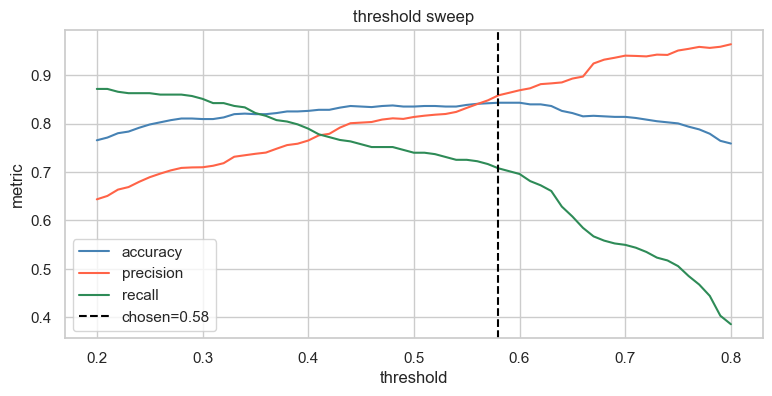

In [11]:
thresholds = np.linspace(0.2, 0.8, 61)
rows = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_true, pred),
        "precision": ((pred == 1) & (y_true == 1)).sum() / max((pred == 1).sum(), 1),
        "recall": ((pred == 1) & (y_true == 1)).sum() / max((y_true == 1).sum(), 1),
    })
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
for col, color in [("accuracy", "steelblue"), ("precision", "tomato"), ("recall", "seagreen")]:
    ax.plot(sweep["threshold"], sweep[col], label=col, color=color)
ax.axvline(metrics["best_threshold"], color="black", linestyle="--",
           label=f"chosen={metrics['best_threshold']:.2f}")
ax.set_xlabel("threshold")
ax.set_ylabel("metric")
ax.set_title("threshold sweep")
ax.legend()
plt.show()

## 10. Adversarial validation report


In [12]:
adv_path = REPORT_DIR / "adversarial_validation.json"
if adv_path.exists():
    adv = json.loads(adv_path.read_text(encoding="utf-8"))
    print(f"AUC: {adv['mean_auc']:.3f}  →  {adv['verdict']}")
    print()
    print("top drifted features:")
    for name, weight in adv["top_drifted"].items():
        print(f"  {name:25} {weight}")
else:
    print(f"no adversarial report at {adv_path}")

AUC: 0.681  →  moderate shift

top drifted features:
  TicketFrequency           1.3084
  PassengerType             0.5227
  Sex                       0.4454
  FamilySize                0.3963
  Parch                     0.3641


## 11. Training curves (learning history)


In [13]:
history_paths = sorted(REPORT_DIR.glob("eval_history_fold_*.csv"))
if not history_paths:
    raise FileNotFoundError(
        "no eval_history_fold_*.csv — run `python -m src.main fit` first"
    )

history = pd.concat(
    [pd.read_csv(path) for path in history_paths],
    ignore_index=True,
)
history.head()

,fold,iteration,dataset,metric,value
0,0,0,learn,Accuracy,0.793539
1,0,1,learn,Accuracy,0.790730
2,0,2,learn,Accuracy,0.787921
3,0,3,learn,Accuracy,0.806180
4,0,4,learn,Accuracy,0.817416


In [14]:
last_metrics = (
    history.sort_values("iteration")
    .groupby(["fold", "metric", "dataset"], as_index=False)
    .tail(1)
    .pivot(index=["fold", "metric"], columns="dataset", values="value")
)
last_metrics

dataset           learn  validation
fold metric                        
0    Accuracy  0.838483    0.843575
     Logloss   0.386103    0.391063
1    Accuracy  0.838710    0.831461
     Logloss   0.388262    0.397429
2    Accuracy  0.841515    0.820225
     Logloss   0.375296    0.426452
3    Accuracy  0.840112    0.842697
     Logloss   0.381842    0.392680
4    Accuracy  0.835905    0.837079
     Logloss   0.383700    0.386592

In [15]:
logloss = history[history["metric"].eq("Logloss")].copy()

best_iter = pd.DataFrame({
    "fold": range(len(metrics.get("fold_scores", []))),
    "score": metrics.get("fold_scores", []),
    "best_iteration": metrics.get("best_iterations", []),
})

logloss_wide = (
    logloss.pivot_table(
        index=["fold", "iteration"],
        columns="dataset",
        values="value",
    )
    .reset_index()
)

best_logloss = best_iter.merge(
    logloss_wide,
    left_on=["fold", "best_iteration"],
    right_on=["fold", "iteration"],
    how="left",
)
best_logloss["gap_at_best"] = best_logloss["validation"] - best_logloss["learn"]

min_validation = (
    logloss[logloss["dataset"].eq("validation")]
    .sort_values("value")
    .groupby("fold", as_index=False)
    .head(1)
    .rename(columns={
        "iteration": "min_validation_iteration",
        "value": "min_validation_logloss",
    })[["fold", "min_validation_iteration", "min_validation_logloss"]]
)

best_logloss = best_logloss.merge(min_validation, on="fold", how="left")
best_logloss[[
    "fold",
    "score",
    "best_iteration",
    "learn",
    "validation",
    "gap_at_best",
    "min_validation_iteration",
    "min_validation_logloss",
]]

,fold,score,best_iteration,learn,validation,gap_at_best,min_validation_iteration,min_validation_logloss
0,0,0.843575,154,0.386103,0.391063,0.004960,154,0.391063
1,1,0.831461,154,0.388262,0.397429,0.009167,154,0.397429
2,2,0.820225,154,0.375296,0.426452,0.051156,154,0.426452
3,3,0.842697,154,0.381842,0.392680,0.010838,154,0.392680
4,4,0.837079,154,0.383700,0.386592,0.002892,154,0.386592


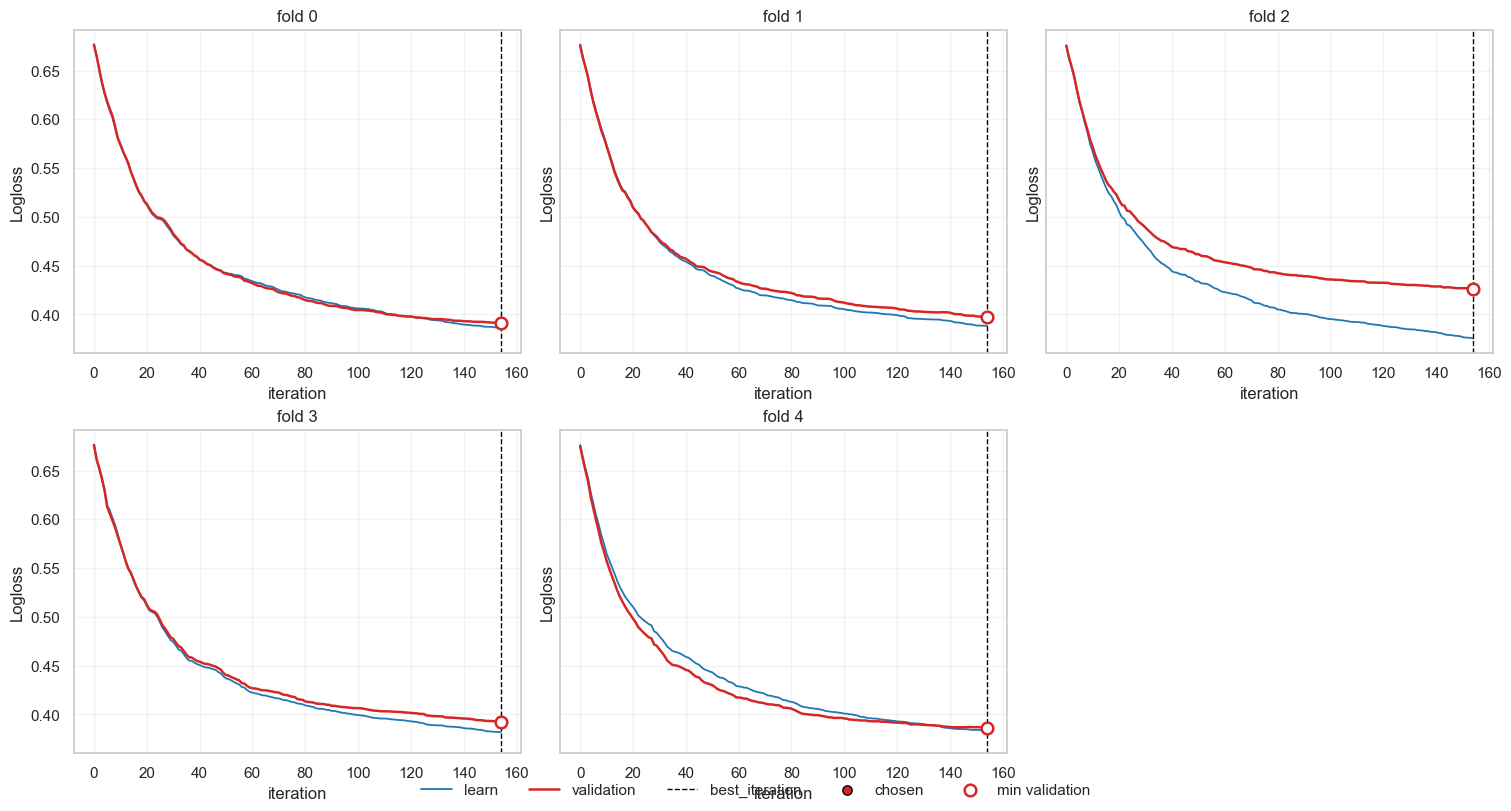

In [16]:
folds = sorted(logloss["fold"].unique())
ncols = 3
nrows = -(-len(folds) // ncols)
colors = {"learn": "#1f77b4", "validation": "#d62728"}
best_iter_map = dict(zip(best_iter["fold"], best_iter["best_iteration"]))
min_validation_map = min_validation.set_index("fold")

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 4 * nrows),
    sharey=True,
    constrained_layout=True,
)
axes = axes.reshape(-1)

for ax, fold in zip(axes, folds):
    fold_logloss = logloss[logloss["fold"].eq(fold)]
    for dataset, color in colors.items():
        part = fold_logloss[fold_logloss["dataset"].eq(dataset)]
        ax.plot(
            part["iteration"],
            part["value"],
            label=dataset,
            color=color,
            linewidth=1.8 if dataset == "validation" else 1.3,
        )

    best_i = best_iter_map.get(fold)
    if pd.notna(best_i):
        ax.axvline(best_i, color="black", linestyle="--", linewidth=1, label="best_iteration")
        chosen = fold_logloss[
            fold_logloss["dataset"].eq("validation")
            & fold_logloss["iteration"].eq(best_i)
        ]
        if not chosen.empty:
            ax.scatter(
                chosen["iteration"],
                chosen["value"],
                color=colors["validation"],
                edgecolor="black",
                s=45,
                zorder=5,
                label="chosen",
            )

    if fold in min_validation_map.index:
        min_row = min_validation_map.loc[fold]
        ax.scatter(
            min_row["min_validation_iteration"],
            min_row["min_validation_logloss"],
            facecolor="white",
            edgecolor=colors["validation"],
            linewidth=1.8,
            s=70,
            zorder=6,
            label="min validation",
        )

    ax.set_title(f"fold {fold}")
    ax.set_xlabel("iteration")
    ax.set_ylabel("Logloss")
    ax.grid(alpha=0.25)

for ax in axes[len(folds):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="lower center",
    ncol=len(by_label),
    frameon=False,
)
plt.show()

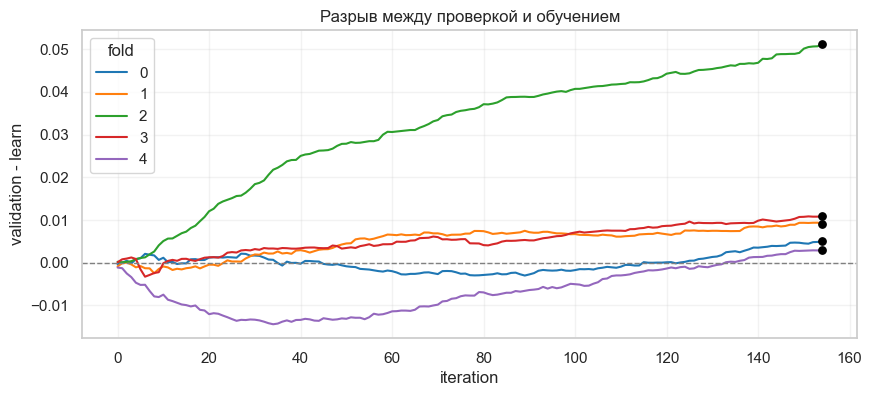

In [17]:
gap = logloss_wide.dropna(subset=["learn", "validation"]).copy()
gap["validation_minus_learn"] = gap["validation"] - gap["learn"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=gap,
    x="iteration",
    y="validation_minus_learn",
    hue="fold",
    palette="tab10",
    ax=ax,
)

for _, row in best_logloss.iterrows():
    ax.scatter(
        row["best_iteration"],
        row["gap_at_best"],
        color="black",
        s=28,
        zorder=5,
    )

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Разрыв между проверкой и обучением")
ax.set_xlabel("iteration")
ax.set_ylabel("validation - learn")
ax.grid(alpha=0.25)
plt.show()

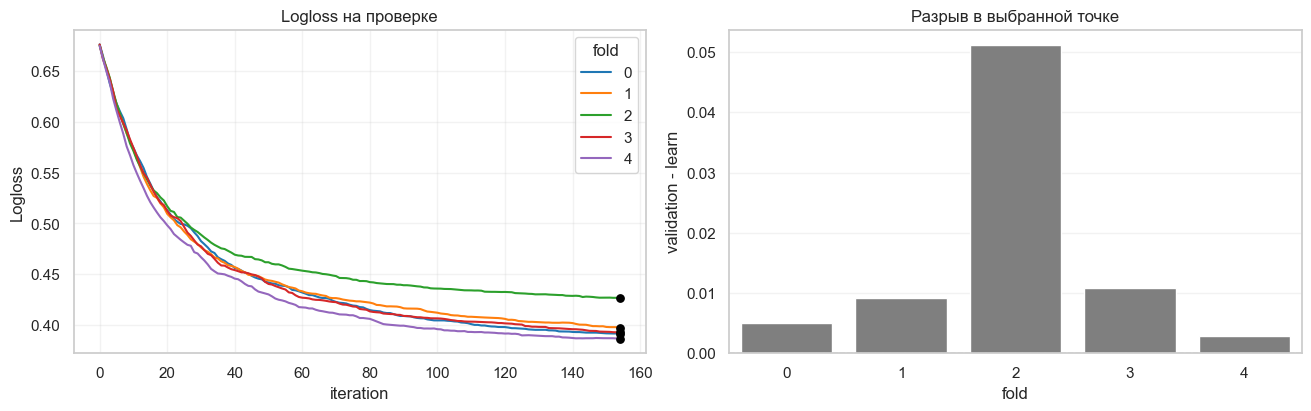

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

sns.lineplot(
    data=logloss[logloss["dataset"].eq("validation")],
    x="iteration",
    y="value",
    hue="fold",
    palette="tab10",
    ax=axes[0],
)
axes[0].scatter(
    best_logloss["best_iteration"],
    best_logloss["validation"],
    color="black",
    s=28,
    zorder=5,
)
axes[0].set_title("Logloss на проверке")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("Logloss")
axes[0].grid(alpha=0.25)

sns.barplot(
    data=best_logloss,
    x="fold",
    y="gap_at_best",
    color="#7f7f7f",
    ax=axes[1],
)
axes[1].axhline(0, color="gray", linewidth=1, linestyle="--")
axes[1].set_title("Разрыв в выбранной точке")
axes[1].set_xlabel("fold")
axes[1].set_ylabel("validation - learn")
axes[1].grid(axis="y", alpha=0.25)

plt.show()

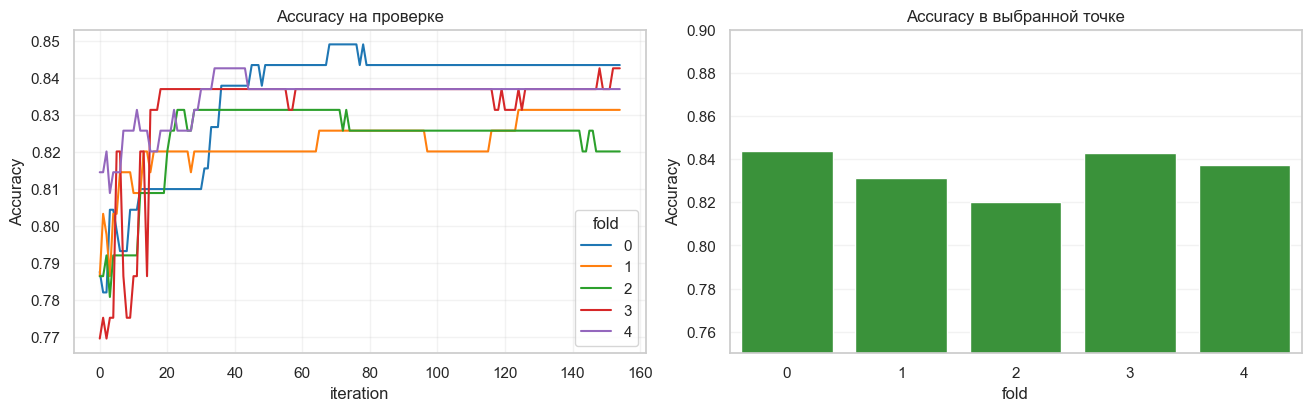

In [19]:
accuracy = history[history["metric"].eq("Accuracy")].copy()

if not accuracy.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

    sns.lineplot(
        data=accuracy[accuracy["dataset"].eq("validation")],
        x="iteration",
        y="value",
        hue="fold",
        palette="tab10",
        ax=axes[0],
    )
    axes[0].set_title("Accuracy на проверке")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(alpha=0.25)

    accuracy_wide = (
        accuracy.pivot_table(
            index=["fold", "iteration"],
            columns="dataset",
            values="value",
        )
        .reset_index()
    )
    best_accuracy = best_iter.merge(
        accuracy_wide,
        left_on=["fold", "best_iteration"],
        right_on=["fold", "iteration"],
        how="left",
    )

    sns.barplot(
        data=best_accuracy,
        x="fold",
        y="validation",
        color="#2ca02c",
        ax=axes[1],
    )
    axes[1].set_title("Accuracy в выбранной точке")
    axes[1].set_xlabel("fold")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.75, 0.9)
    axes[1].grid(axis="y", alpha=0.25)

    plt.show()

In [20]:
last_logloss = (
    logloss.sort_values("iteration")
    .groupby(["fold", "dataset"], as_index=False)
    .tail(1)
    .pivot(index="fold", columns="dataset", values="value")
)

if {"learn", "validation"}.issubset(last_logloss.columns):
    last_logloss["validation_minus_learn"] = (
        last_logloss["validation"] - last_logloss["learn"]
    )

last_logloss

dataset,learn,validation,validation_minus_learn
fold,,,
0,0.386103,0.391063,0.004960
1,0.388262,0.397429,0.009167
2,0.375296,0.426452,0.051156
3,0.381842,0.392680,0.010838
4,0.383700,0.386592,0.002892


## 12. Permutation importance


In [21]:
import sys

if str(PROJECT_ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.resolve()))

import joblib
from sklearn.inspection import permutation_importance

from src.config import load_experiment_config_by_name
from src.features import (
    CATEGORICAL,
    apply_preprocessing_artifacts,
    build_base_features,
)

MODEL_DIR = PROJECT_ROOT / "models" / EXPERIMENT
CONFIG = load_experiment_config_by_name(PROJECT_ROOT, EXPERIMENT)
fold_paths = sorted(
    p for p in MODEL_DIR.glob("fold_*.joblib")
    if not p.stem.endswith("_artifacts")
)
print(f"folds: {len(fold_paths)}")

folds: 5


In [22]:
perm_per_fold = []
for path in fold_paths:
    fold = int(path.stem.split("_")[1])
    model = joblib.load(path)
    artifacts = joblib.load(MODEL_DIR / f"fold_{fold}_artifacts.joblib")

    fold_oof = oof[oof["fold"] == fold]
    fold_data = train[train["PassengerId"].isin(fold_oof["PassengerId"])].reset_index(drop=True)
    base = build_base_features(fold_data, CONFIG)
    X = apply_preprocessing_artifacts(base, artifacts, CONFIG)
    y = fold_data["Survived"]

    result = permutation_importance(
        model, X, y, n_repeats=10, random_state=42, scoring="accuracy",
    )
    perm_per_fold.append(pd.Series(result.importances_mean, index=X.columns, name=f"fold_{fold}"))

perm_df = pd.concat(perm_per_fold, axis=1)
perm = pd.DataFrame({
    "perm_mean": perm_df.mean(axis=1),
    "perm_std": perm_df.std(axis=1),
}).sort_values("perm_mean", ascending=False)
perm.round(4)

,perm_mean,perm_std
PassengerType,0.0704,0.0082
Title,0.0526,0.0102
Pclass,0.0038,0.0047
Deck,0.0034,0.0068
HasCabin,0.0030,0.0048
NaNCount,0.0025,0.0049
FarePerPerson,0.0010,0.0031
Fare,0.0009,0.0038
TicketFrequency,0.0001,0.0005
FamilySurvivalRate,-0.0002,0.0056


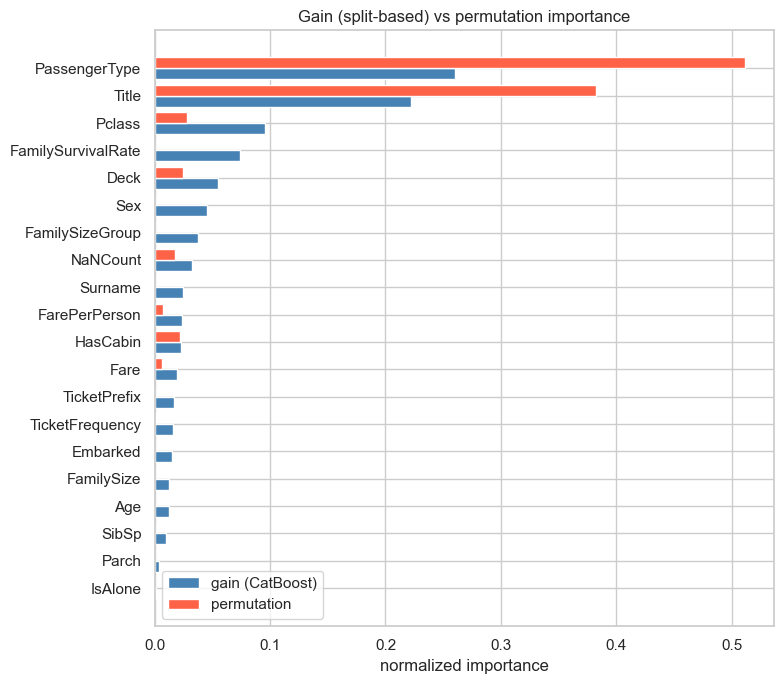

In [23]:
# Compare gain vs permutation, both normalized
gain = importance.set_index("feature")["mean_importance"]
gain_norm = (gain / gain.sum()).rename("gain")
perm_norm = (perm["perm_mean"].clip(lower=0) / perm["perm_mean"].clip(lower=0).sum()).rename("permutation")

merged = pd.concat([gain_norm, perm_norm], axis=1).fillna(0).sort_values("gain", ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
y_pos = np.arange(len(merged))
ax.barh(y_pos - 0.2, merged["gain"], height=0.4, color="steelblue", label="gain (CatBoost)")
ax.barh(y_pos + 0.2, merged["permutation"], height=0.4, color="tomato", label="permutation")
ax.set_yticks(y_pos)
ax.set_yticklabels(merged.index)
ax.set_xlabel("normalized importance")
ax.set_title("Gain (split-based) vs permutation importance")
ax.legend()
plt.tight_layout()
plt.show()

## 13. SHAP — global summary


In [24]:
import shap

FOLD = 0
model = joblib.load(MODEL_DIR / f"fold_{FOLD}.joblib")
artifacts = joblib.load(MODEL_DIR / f"fold_{FOLD}_artifacts.joblib")

fold_oof = oof[oof["fold"] == FOLD]
fold_data = train[train["PassengerId"].isin(fold_oof["PassengerId"])].reset_index(drop=True)
base = build_base_features(fold_data, CONFIG)
X = apply_preprocessing_artifacts(base, artifacts, CONFIG)
y = fold_data["Survived"]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
print(f"shap shape: {shap_values.values.shape}, n_samples: {len(X)}")

C:\Users\kamaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap shape: (179, 20), n_samples: 179


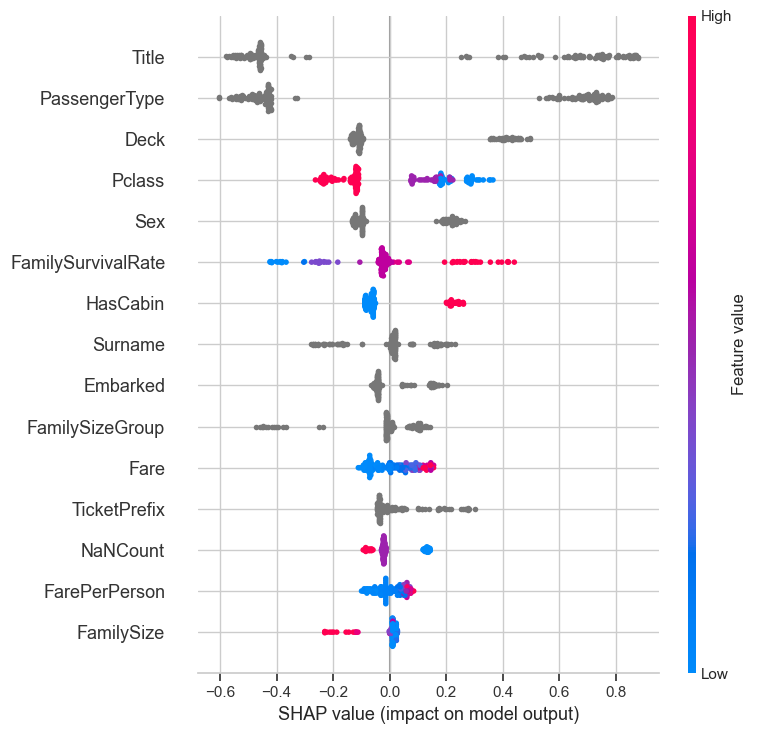

In [25]:
shap.summary_plot(shap_values, X, max_display=15, show=False)
plt.tight_layout()
plt.show()

## 14. SHAP — dependence plots


In [26]:
# Топ-3 фичи по gain (могут отличаться от топа SHAP — это интересно)
top_features = importance.head(3)["feature"].tolist()
top_features = [f for f in top_features if f in X.columns]
print(f"top features for dependence plots: {top_features}")

top features for dependence plots: ['PassengerType', 'Title', 'Pclass']


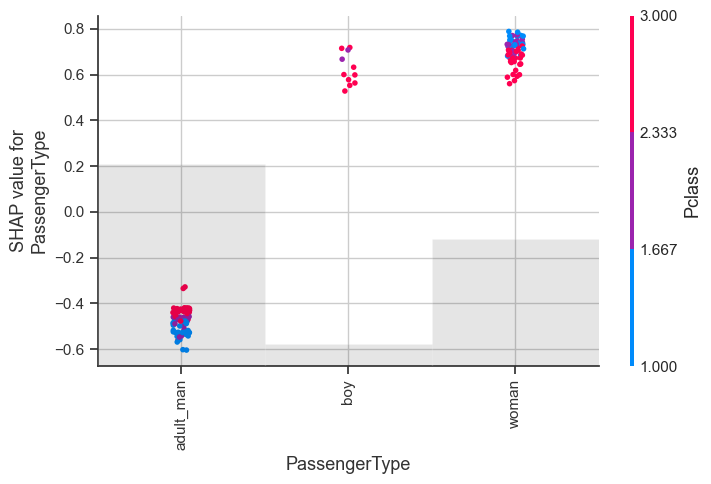

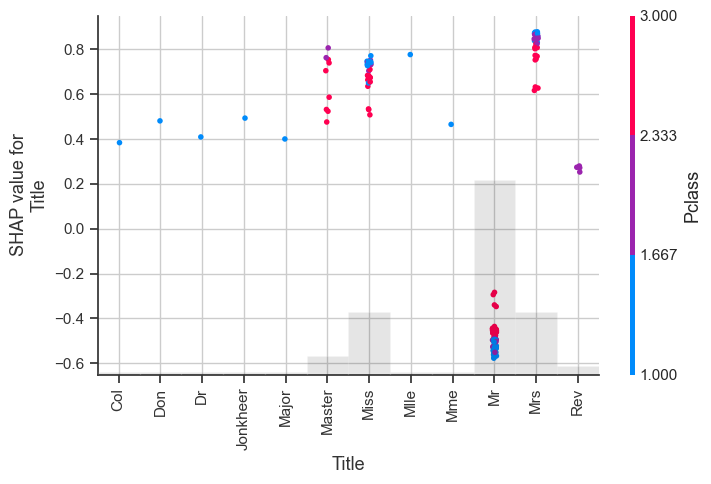

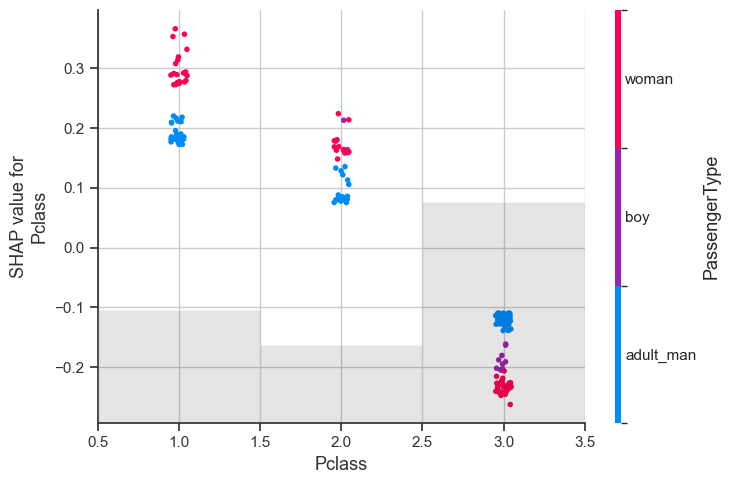

In [27]:
for feature in top_features:
    shap.plots.scatter(shap_values[:, feature], color=shap_values, show=False)
    plt.tight_layout()
    plt.show()

## 15. SHAP — single-example waterfall


In [28]:
# Find a high-confidence wrong prediction in this fold
fold_with_pred = fold_data.merge(
    fold_oof[["PassengerId", "probability", "prediction"]],
    on="PassengerId",
)
fold_with_pred["correct"] = fold_with_pred["Survived"] == fold_with_pred["prediction"]
fold_with_pred["confidence"] = (fold_with_pred["probability"] - 0.5).abs() + 0.5

worst = fold_with_pred[~fold_with_pred["correct"]].nlargest(1, "confidence")
if len(worst):
    target_id = int(worst["PassengerId"].iloc[0])
    idx = int(fold_data.index[fold_data["PassengerId"] == target_id][0])
    print(f"Passenger {target_id}: actual={int(worst['Survived'].iloc[0])}, "
          f"predicted={int(worst['prediction'].iloc[0])}, "
          f"prob={worst['probability'].iloc[0]:.3f}")
    print()
    print("raw features:")
    print(fold_data.loc[idx, ["Pclass", "Sex", "Age", "Fare", "Embarked", "Name"]].to_string())
else:
    target_id, idx = None, None
    print("no misclassified samples in this fold (unlikely)")

Passenger 178: actual=0, predicted=1, prob=0.941

raw features:
Pclass                               1
Sex                             female
Age                               50.0
Fare                           28.7125
Embarked                             C
Name        Isham, Miss. Ann Elizabeth


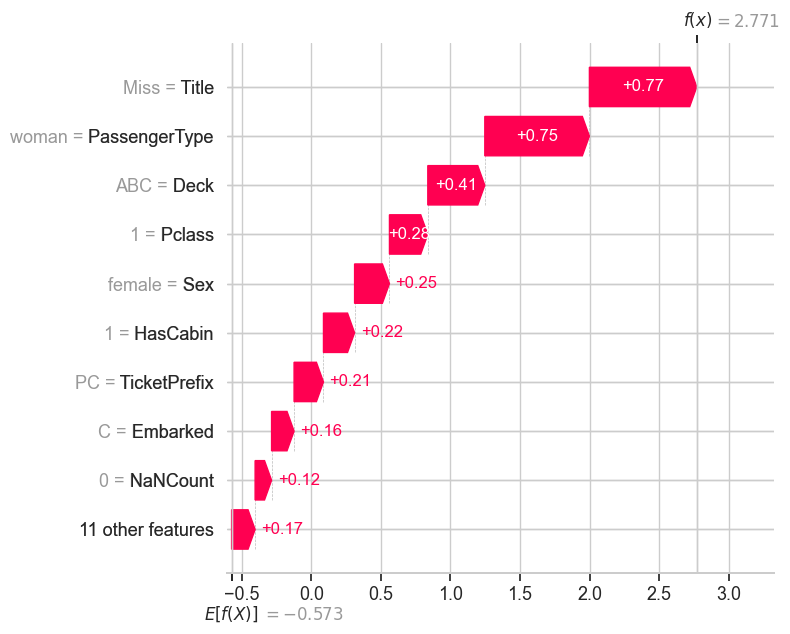

In [29]:
if idx is not None:
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.tight_layout()
    plt.show()

## 16. Feature selection


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

artifacts_for_mi = joblib.load(MODEL_DIR / "fold_0_artifacts.joblib")
base_full = build_base_features(train, CONFIG)
X_full = apply_preprocessing_artifacts(base_full, artifacts_for_mi, CONFIG)
y_full = train["Survived"]

X_mi = X_full.copy()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_mi[CATEGORICAL] = encoder.fit_transform(X_mi[CATEGORICAL].astype(str))

discrete_idx = [X_mi.columns.get_loc(c) for c in CATEGORICAL]
mi_values = mutual_info_classif(
    X_mi, y_full, random_state=42, discrete_features=discrete_idx,
)
mi = pd.Series(mi_values, index=X_mi.columns, name="mutual_info")
mi.sort_values(ascending=False).round(4)

Surname               0.5487
FamilySurvivalRate    0.4280
Title                 0.1780
PassengerType         0.1662
Sex                   0.1509
FarePerPerson         0.1439
Fare                  0.1366
Pclass                0.0739
Age                   0.0620
Deck                  0.0523
FamilySize            0.0497
FamilySizeGroup       0.0421
NaNCount              0.0393
TicketPrefix          0.0383
HasCabin              0.0344
TicketFrequency       0.0215
IsAlone               0.0201
Embarked              0.0142
SibSp                 0.0046
Parch                 0.0000
Name: mutual_info, dtype: float64

In [ ]:
combined = pd.concat([
    gain.rename("gain"),
    perm["perm_mean"].rename("permutation"),
    mi,
], axis=1)

combined["gain_rank"] = combined["gain"].rank(ascending=False).astype(int)
combined["perm_rank"] = combined["permutation"].rank(ascending=False).astype(int)
combined["mi_rank"] = combined["mutual_info"].rank(ascending=False).astype(int)
combined["consensus"] = combined[["gain_rank", "perm_rank", "mi_rank"]].mean(axis=1)

combined.sort_values("consensus").round(4)

,gain,permutation,mutual_info,gain_rank,perm_rank,mi_rank,consensus
PassengerType,26.0032,0.0704,0.1662,1,1,4,2.0000
Title,22.2075,0.0526,0.1780,2,2,3,2.3333
Pclass,9.5349,0.0038,0.0739,3,3,8,4.6667
FamilySurvivalRate,7.3738,-0.0002,0.4280,4,10,2,5.3333
Deck,5.5152,0.0034,0.0523,5,4,10,6.3333
FarePerPerson,2.4038,0.0010,0.1439,10,7,6,7.6667
Surname,2.4168,-0.0010,0.5487,9,15,1,8.3333
NaNCount,3.2644,0.0025,0.0393,8,6,13,9.0000
Fare,1.9264,0.0009,0.1366,12,8,7,9.0000
Sex,4.5477,-0.0039,0.1509,6,19,5,10.0000


In [ ]:
print("bottom 5 by consensus (low importance across all 3 methods):")
print(combined.nlargest(5, "consensus")[
    ["gain", "permutation", "mutual_info", "consensus"]
].round(4))
print()


bottom 5 by consensus (low importance across all 3 methods):
              gain  permutation  mutual_info  consensus
Parch       0.3751      -0.0021       0.0000    19.0000
SibSp       0.9921      -0.0016       0.0046    18.0000
IsAlone     0.1447      -0.0009       0.0201    17.0000
Embarked    1.5148      -0.0009       0.0142    15.3333
FamilySize  1.2678      -0.0015       0.0497    14.3333

